<a href="https://colab.research.google.com/github/bavucadoz/244107020162_ML_2026/blob/main/Quiz01/00_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 00 - Preprocessing Data

**Dataset:** `Transactions.csv` (transaksi kasir 3 outlet, Jan-Sep 2025).
**Tujuan:** mengubah data struk menjadi tabel fitur **per produk di tiap outlet**
(`Outlet × Item`) yang siap diklaster.

## Alur

```
Data asli (struk transaksi)
   ↓  bersihkan + pecah struk multi-item
Data penjualan per item
   ↓  buat deret harian (hari tanpa jual = 0)
Deret waktu harian
   ↓  hitung fitur perilaku permintaan
Tabel fitur Outlet × Item
   ↓  buang fitur redundan + log + StandardScaler
X_scaled  →  dipakai K-Means & DBSCAN
```

## Rumus Standarisasi (Z-Score)

$$z = \frac{x - \mu}{\sigma}$$

$\mu$ = rata-rata kolom, $\sigma$ = simpangan baku kolom. Agar semua fitur
berkontribusi setara saat menghitung jarak.

## Rumus Fitur Utama

- rata-rata harian: $\bar d = \frac{1}{T}\sum_{t=1}^{T} q_t$
- koefisien variasi: $cv = \frac{\sigma_d}{\bar d}$ (besar $cv$ -> permintaan tidak stabil)
- rasio hari kosong: $\text{zero\_ratio} = \frac{\#\{q_t = 0\}}{T}$
- rasio akhir pekan: $\text{weekend\_ratio} = \frac{\bar d_{akhir\ pekan}}{\bar d_{hari\ kerja}}$

dengan $q_t$ = jumlah item terjual pada hari ke-$t$, $T$ = jumlah hari.

## 0. Import & Konfigurasi

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy import stats

np.random.seed(42)

folder = 'Clustering_Stok'          # folder hasil, dibaca notebook 01-03
os.makedirs(folder, exist_ok=True)

CSV_FILE = 'data/Transactions.csv'  # lokasi file data
if not os.path.exists(CSV_FILE):
    CSV_FILE = 'Transactions.csv'

CORR_THRESHOLD = 0.90               # fitur dengan |korelasi| >= ini dianggap kembar

## 1. Memuat Data & Audit Kualitas

In [2]:
df_raw = pd.read_csv(CSV_FILE)
df_raw.head()

,Outlet,Date,Time,NetSales,Tax,TotalAmount,ReceiptNumber,Items,TotalItem,PaymentMethod,UseLoyaltyCard
0,SHOP001,2025-01-02,07:01:05,20720.721,2279.279,23000,SHOP001JAN2500001,Basic Latte (Ice Arabica),1,BCA,0
1,SHOP001,2025-01-02,07:04:11,18018.018,1981.982,20000,SHOP001JAN2500002,BLACK (Houseblend),1,BCA,0
2,SHOP002,2025-01-02,07:10:46,39639.640,4360.360,44000,SHOP002JAN2500001,"Friendly Coffee (Hot), Shakencano",2,Cash,0
3,SHOP002,2025-01-02,07:14:25,36036.036,3963.964,40000,SHOP002JAN2500002,"BLACK (Arabica), Americano (Hot Arabica)",2,Cash,0
4,SHOP002,2025-01-02,07:23:05,36036.036,3963.964,40000,SHOP002JAN2500003,"WHITE (Arabica), Susu Oat",2,Cash,0


In [3]:
print('Jumlah baris                     :', f'{df_raw.shape[0]:,}')
print('Jumlah kolom                     :', df_raw.shape[1])
print('Missing value total              :', int(df_raw.isna().sum().sum()))
print('Nomor struk duplikat             :', int(df_raw['ReceiptNumber'].duplicated().sum()))
print('Transaksi gratis (TotalAmount=0) :', int((df_raw['TotalAmount'] == 0).sum()))
print('Rentang tanggal                  :', df_raw['Date'].min(), 's/d', df_raw['Date'].max())
print('Outlet                           :', sorted(df_raw['Outlet'].unique()))

Jumlah baris                     : 53,820
Jumlah kolom                     : 11
Missing value total              : 0
Nomor struk duplikat             : 0
Transaksi gratis (TotalAmount=0) : 1733
Rentang tanggal                  : 2025-01-02 s/d 2025-09-30
Outlet                           : ['SHOP001', 'SHOP002', 'SHOP003']


## 2. Pembersihan & Pecah Struk Multi-Item

Satu struk bisa berisi beberapa item (`"A, B"`). Kita pecah agar satu baris
= satu item terjual. Transaksi gratis (kartu loyalitas) **tetap dihitung**
karena barangnya tetap keluar dari stok.

In [4]:
df = df_raw.copy()
df['Date'] = pd.to_datetime(df['Date'])
df['hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour
df['Items'] = df['Items'].str.strip().str.replace('Houesblend', 'Houseblend', regex=False)
df['is_free'] = (df['TotalAmount'] == 0).astype(int)
df = df.drop_duplicates(subset='ReceiptNumber')

# pecah struk "A, B" menjadi satu baris per item
df['item_list'] = df['Items'].str.split(r',\s*')
ex = df.explode('item_list').rename(columns={'item_list': 'Item'})
ex['Item'] = ex['Item'].str.strip()

# harga per item = median TotalAmount pada struk 1 item berbayar
single = df[(df['TotalItem'] == 1) & (df['TotalAmount'] > 0)]
price_map = single.groupby('Items')['TotalAmount'].median()
ex['price'] = ex['Item'].map(price_map).fillna(price_map.median())

print(f'{len(df):,} struk -> {len(ex):,} item terjual')
print(f'{ex["Item"].nunique()} produk unik | {ex["Outlet"].nunique()} outlet')

53,820 struk -> 61,973 item terjual
94 produk unik | 3 outlet


## 3. Deret Waktu Harian (Zero-Filled)

Hari tanpa penjualan harus dicatat **0**, bukan hilang. Kalau hilang, rata-rata
permintaan jadi terlalu tinggi dan prediksi stok meleset.

In [5]:
all_dates = pd.date_range(ex['Date'].min(), ex['Date'].max(), freq='D')
cnt = ex.groupby(['Outlet', 'Item', 'Date']).size().rename('qty')
full_idx = pd.MultiIndex.from_product(
    [sorted(ex['Outlet'].unique()), sorted(ex['Item'].unique()), all_dates],
    names=['Outlet', 'Item', 'Date'])
daily = cnt.reindex(full_idx, fill_value=0).reset_index()
daily['dow'] = daily['Date'].dt.dayofweek

print('Deret harian          :', f'{len(daily):,} baris')
print('Hari tanpa penjualan  :', f"{(daily['qty'] == 0).mean() * 100:.1f}%")

Deret harian          : 76,704 baris
Hari tanpa penjualan  : 46.8%


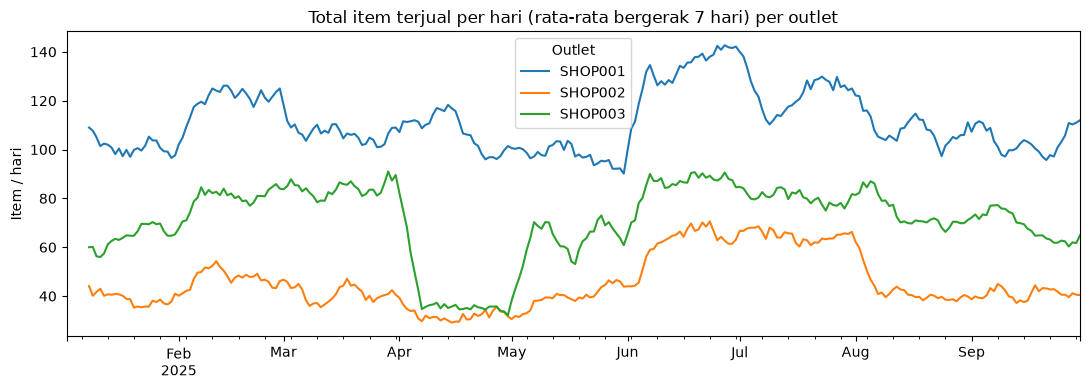

In [6]:
ax = daily.groupby(['Date', 'Outlet'])['qty'].sum().unstack().rolling(7).mean().plot(figsize=(11, 4))
ax.set_title('Total item terjual per hari (rata-rata bergerak 7 hari) per outlet')
ax.set_ylabel('Item / hari')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

## 4. Rekayasa Fitur per `Outlet × Item`

| Fitur | Arti |
|---|---|
| `mean_daily` | rata-rata terjual per hari |
| `std_daily`, `cv` | variabilitas permintaan |
| `zero_day_ratio` | proporsi hari tanpa penjualan |
| `max_daily` | puncak penjualan harian |
| `trend_weekly_pct` | arah tren mingguan |
| `weekend_ratio` | pola akhir pekan |
| `momentum_30d` | kondisi 30 hari terakhir |
| `share_morning`, `share_evening` | porsi jam ramai |
| `loyalty_share` | porsi penjualan gratis |
| `avg_price` | harga rata-rata |

In [7]:
agg_hour = ex.groupby(['Outlet', 'Item']).agg(
    share_morning=('hour', lambda h: (h < 12).mean()),
    share_evening=('hour', lambda h: (h >= 17).mean()),
    loyalty_share=('is_free', 'mean'),
    avg_price=('price', 'mean')).reset_index()

rows = []
for (o, i), g in daily.groupby(['Outlet', 'Item']):
    q = g['qty'].values
    wk = g.set_index('Date')['qty'].resample('W').sum().values
    wk = wk[1:-1] if len(wk) > 4 else wk
    slope = stats.linregress(np.arange(len(wk)), wk).slope if len(wk) >= 3 else 0.0
    wkend = g['dow'].values >= 5
    mean = q.mean()
    rows.append({'Outlet': o, 'Item': i, 'total_qty': int(q.sum()),
                 'mean_daily': mean, 'std_daily': q.std(), 'cv': q.std() / mean if mean > 0 else 0.0,
                 'zero_day_ratio': (q == 0).mean(), 'max_daily': q.max(),
                 'trend_weekly_pct': slope / wk.mean() if wk.mean() > 0 else 0.0,
                 'weekend_ratio': (q[wkend].mean() / q[~wkend].mean()) if q[~wkend].mean() > 0 else 1.0,
                 'momentum_30d': q[-30:].mean() / mean if mean > 0 else 1.0})
features_df = pd.DataFrame(rows).merge(agg_hour, on=['Outlet', 'Item'])
features_df['revenue_est'] = features_df['total_qty'] * features_df['avg_price']

print('Tabel fitur:', features_df.shape)

Tabel fitur: (282, 16)


In [8]:
features_df.head()

,Outlet,Item,total_qty,mean_daily,std_daily,cv,zero_day_ratio,max_daily,trend_weekly_pct,weekend_ratio,momentum_30d,share_morning,share_evening,loyalty_share,avg_price,revenue_est
0,SHOP001,Air Mineral,325,1.194853,1.044370,0.874057,0.272059,5,-0.004210,0.982062,0.836923,0.273846,0.467692,0.0,5000.0,1625000.0
1,SHOP001,Americano (Hot Arabica),340,1.250000,1.183527,0.946821,0.305147,6,0.001179,1.096045,0.986667,0.270588,0.420588,0.0,20000.0,6800000.0
2,SHOP001,Americano (Hot Houseblend),282,1.036765,0.999324,0.963887,0.352941,6,0.002489,1.091313,0.868085,0.304965,0.450355,0.0,20000.0,5640000.0
3,SHOP001,Americano (Ice Arabica),318,1.169118,1.098496,0.939594,0.338235,5,-0.003560,1.140908,0.798323,0.292453,0.411950,0.0,20000.0,6360000.0
4,SHOP001,Americano (Ice Houseblend),329,1.209559,1.048555,0.866890,0.275735,5,-0.001712,0.965487,0.936981,0.310030,0.401216,0.0,20000.0,6580000.0


## 5. Buang Fitur Redundan (Korelasi Tinggi)

Kalau dua fitur hampir kembar (|korelasi| >= 0.90), salah satu dibuang agar
"sifat" itu tidak dihitung dua kali saat menghitung jarak.

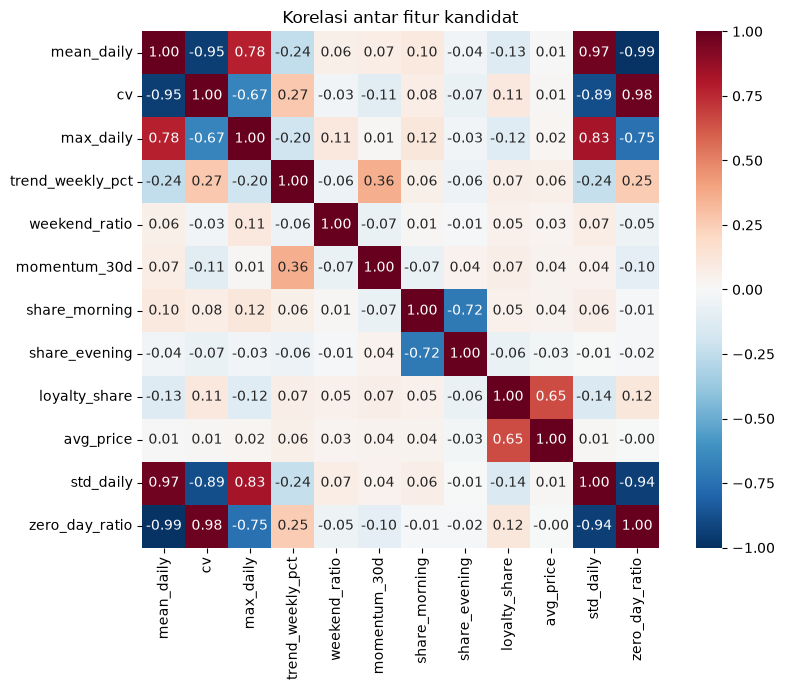

In [9]:
CANDIDATES = ['mean_daily', 'cv', 'max_daily', 'trend_weekly_pct', 'weekend_ratio', 'momentum_30d',
              'share_morning', 'share_evening', 'loyalty_share', 'avg_price', 'std_daily', 'zero_day_ratio']

corr_all = features_df[CANDIDATES].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr_all, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True)
plt.title('Korelasi antar fitur kandidat')
plt.tight_layout()
plt.show()

In [10]:
keep, dropped = [], []
for c in CANDIDATES:
    partner = next((k for k in keep if abs(corr_all.loc[c, k]) >= CORR_THRESHOLD), None)
    if partner is None:
        keep.append(c)
    else:
        dropped.append((c, partner, corr_all.loc[c, partner]))
FEATURES = keep

for c, p, r in dropped:
    print(f'[DIBUANG] {c:<16} redundan dengan {p} (r = {r:+.2f})')
print(f'Fitur dipakai ({len(FEATURES)}): {FEATURES}')

[DIBUANG] cv               redundan dengan mean_daily (r = -0.95)
[DIBUANG] std_daily        redundan dengan mean_daily (r = +0.97)
[DIBUANG] zero_day_ratio   redundan dengan mean_daily (r = -0.99)
Fitur dipakai (9): ['mean_daily', 'max_daily', 'trend_weekly_pct', 'weekend_ratio', 'momentum_30d', 'share_morning', 'share_evening', 'loyalty_share', 'avg_price']


## 6. Log-Transform & Standarisasi

Fitur yang sangat miring (|skewness| > 1) di-`log1p` dulu agar sebarannya lebih
normal, lalu semua fitur di-Z-score.

In [11]:
X_df = features_df[FEATURES].copy()
skew = X_df.skew()
log_cols = [c for c in FEATURES if abs(skew[c]) > 1 and (X_df[c] >= 0).all()]
for c in log_cols:
    X_df[c] = np.log1p(X_df[c])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df.values)
print('Log-transform :', log_cols if log_cols else 'tidak ada fitur yang perlu')
print('Matriks siap klaster:', X_scaled.shape)

Log-transform : tidak ada fitur yang perlu
Matriks siap klaster: (282, 9)


## 7. Simpan Hasil

In [12]:
Xs_df = pd.DataFrame(X_scaled, columns=FEATURES)
Xs_df.insert(0, 'Outlet', features_df['Outlet'].values)
Xs_df.insert(1, 'Item', features_df['Item'].values)
Xs_df.to_csv(f'{folder}/X_scaled.csv', index=False)
features_df.to_csv(f'{folder}/fitur_produk_outlet.csv', index=False)
daily.to_csv(f'{folder}/daily_sales_timeseries.csv', index=False)
json.dump({'features': FEATURES, 'log_transformed': log_cols, 'n_samples': int(X_scaled.shape[0])},
          open(f'{folder}/meta.json', 'w'), indent=2)

print('Tersimpan di folder:', folder)
print('- X_scaled.csv               (fitur siap klaster)')
print('- fitur_produk_outlet.csv    (fitur satuan asli)')
print('- daily_sales_timeseries.csv (deret harian)')
print('- meta.json                  (daftar fitur)')

Tersimpan di folder: Clustering_Stok
- X_scaled.csv               (fitur siap klaster)
- fitur_produk_outlet.csv    (fitur satuan asli)
- daily_sales_timeseries.csv (deret harian)
- meta.json                  (daftar fitur)


## Kesimpulan

Data siap klaster tersimpan di `Clustering_Stok/X_scaled.csv`. Lanjut ke
`01_KMeans_Euclidean.ipynb`.